# 02 Design a Polymer From a User Request

Use this notebook when someone says something like:

- "I want PHB with 6 repeat units."
- "I want a PHA with a five-carbon side chain."
- "I have a custom 3-hydroxy acid monomer SMILES."

The notebook has three design modes. Use **one mode at a time**.

## Available common PHAs

If your polymer is in this table, use **Mode A** below. The side-chain carbon count is the number of carbons in the side group attached to the PHA backbone.

In [1]:
import pandas as pd

from iphasimulator.workflows import PolymerDesign, design_polymer, supported_polymer_table

pd.DataFrame(supported_polymer_table())

,code,polymer_name,side_chain_carbons,monomer_smiles
0,PHB,poly(3-hydroxybutyrate),1,C[C@@H](O)CC(=O)O
1,PHV,poly(3-hydroxyvalerate),2,CC[C@@H](O)CC(=O)O
2,PHHx,poly(3-hydroxyhexanoate),3,CCC[C@@H](O)CC(=O)O
3,PHHep,poly(3-hydroxyheptanoate),4,CCCC[C@@H](O)CC(=O)O
4,PHO,poly(3-hydroxyoctanoate),5,CCCCC[C@@H](O)CC(=O)O
5,PHN,poly(3-hydroxynonanoate),6,CCCCCC[C@@H](O)CC(=O)O
6,PHD,poly(3-hydroxydecanoate),7,CCCCCCC[C@@H](O)CC(=O)O
7,PHDD,poly(3-hydroxydodecanoate),9,CCCCCCCCC[C@@H](O)CC(=O)O


## Mode A: Choose a common polymer name

Edit `common_name` and `degree`. Examples of `common_name` are `PHB`, `PHV`, `PHO`, and `PHDD`.

In [2]:
request = PolymerDesign(
    common_name="PHB",
    degree=4,
)

polymer_name, polymer_mol = design_polymer(request)
polymer_name

'PHB4_R'

## Mode B: Choose a linear side-chain length

Use this when you know the polymer should be a regular linear alkyl-side-chain PHA, but it is not one of the curated names. For example, `side_chain_carbons = 12` creates a PHA repeat unit with a 12-carbon side chain.

Only use positive whole numbers.

In [3]:
request = PolymerDesign(
    side_chain_carbons=5,
    degree=4,
)

polymer_name, polymer_mol = design_polymer(request)
polymer_name

'PHA_C5_4_R'

## Mode C: Use a custom monomer SMILES

Use this for branched, unsaturated, or functionalised side chains. The current custom builder expects an **R 3-hydroxy acid monomer** with one PHA backbone stereocentre.

Example custom monomers:

- Branched side chain: `CC(C)[C@H](O)CC(=O)O`
- Unsaturated side chain: `C=C[C@H](O)CC(=O)O`
- Ether-containing side chain: `COC[C@H](O)CC(=O)O`

If a custom SMILES fails, first check that the stereocentre is R and that the molecule is a 3-hydroxy acid.

In [4]:
request = PolymerDesign(
    custom_monomer_smiles="C=C[C@H](O)CC(=O)O",
    degree=3,
    name="unsaturated_pha",
)

polymer_name, polymer_mol = design_polymer(request)
polymer_name

'unsaturated_pha3_R'

## Quick visual check

The selected `polymer_mol` from the last mode you ran is shown below. This is a quick sanity check before export or simulation preparation.

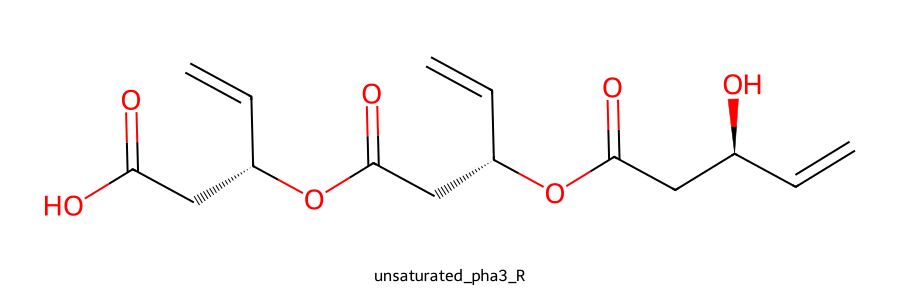

In [5]:
from rdkit.Chem import Draw

Draw.MolToImage(polymer_mol, size=(900, 300), legend=polymer_name)